# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


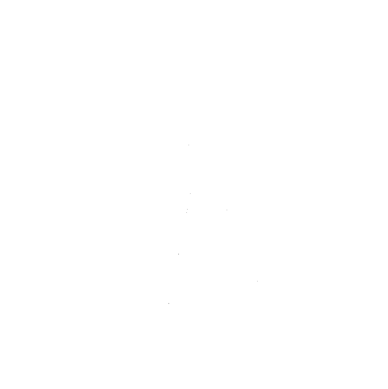

Threshold value: 50


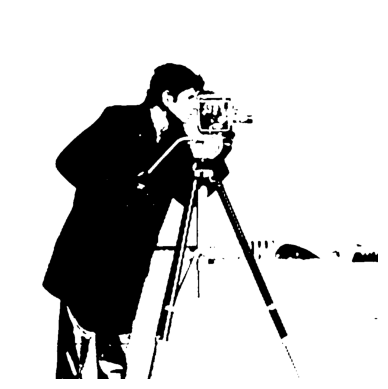

Threshold value: 100


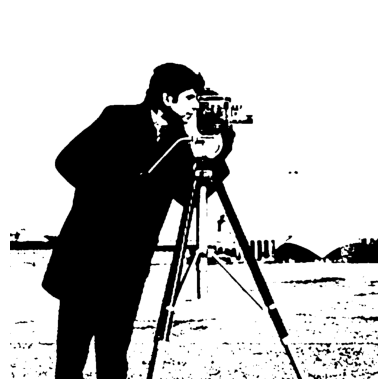

Threshold value: 150


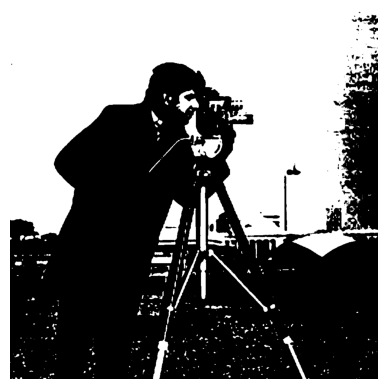

Threshold value: 200


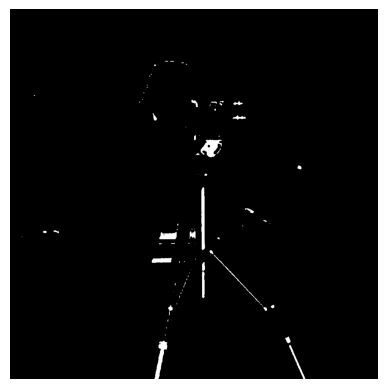

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    ret, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")

    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image:


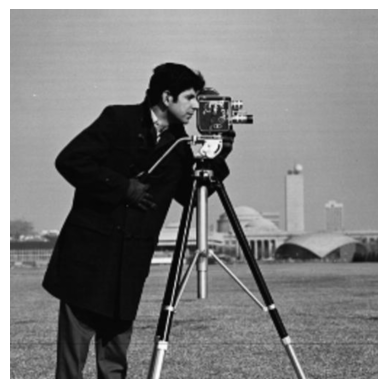

In [3]:
print("Original Image:")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

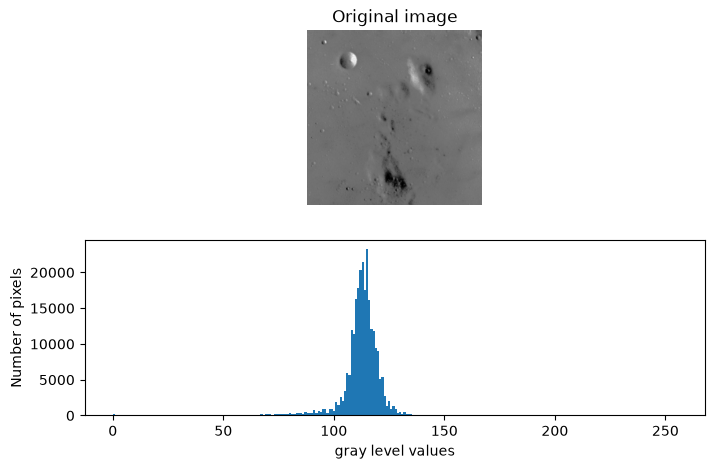

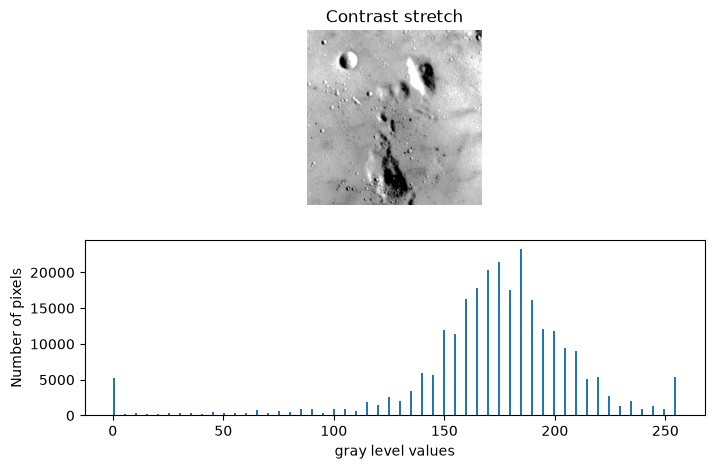

In [4]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


### Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

3rd percentile: 87.0
80th percentile: 118.0


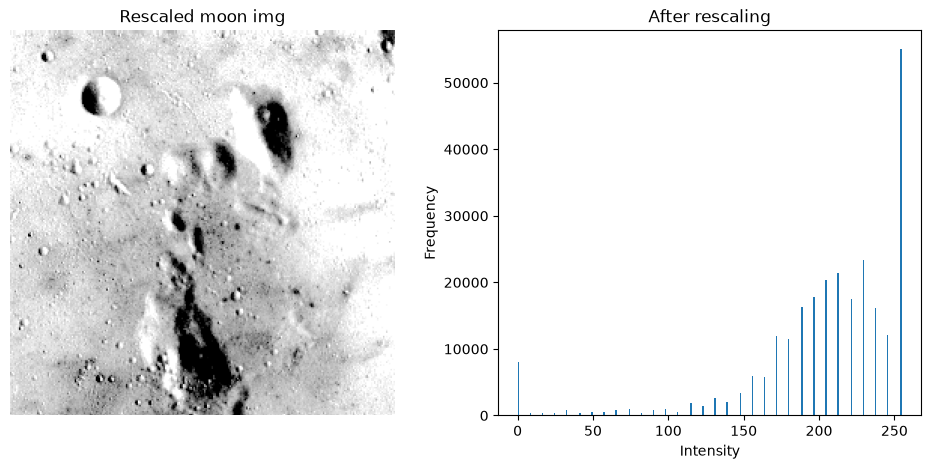

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

# loading the img
moon = data.moon()

# the third and 80th percentiles
p3, p80 = np.percentile(moon, (3, 80))

print("3rd percentile:", p3)
print("80th percentile:", p80)

moon_rescaled = exposure.rescale_intensity(moon, in_range=(p3, p80))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(moon_rescaled, cmap='gray')
plt.title('Rescaled moon img')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(moon_rescaled.ravel(), bins=256)
plt.title('After rescaling')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.show()

### Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

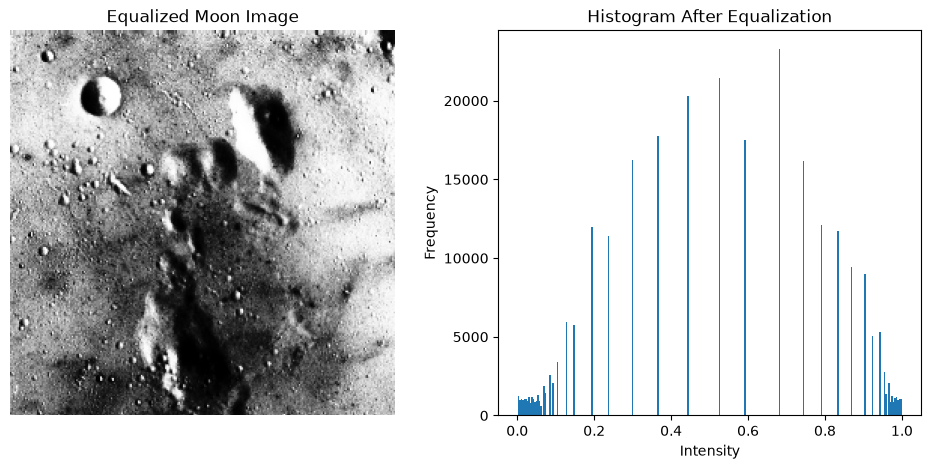

In [13]:
# histogram equalization
moon_equalized = exposure.equalize_hist(moon)

# Display the equalized image
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(moon_equalized, cmap='gray')
plt.title('Equalized Moon Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(moon_equalized.ravel(), bins=256)
plt.title('Histogram After Equalization')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.show()

### Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

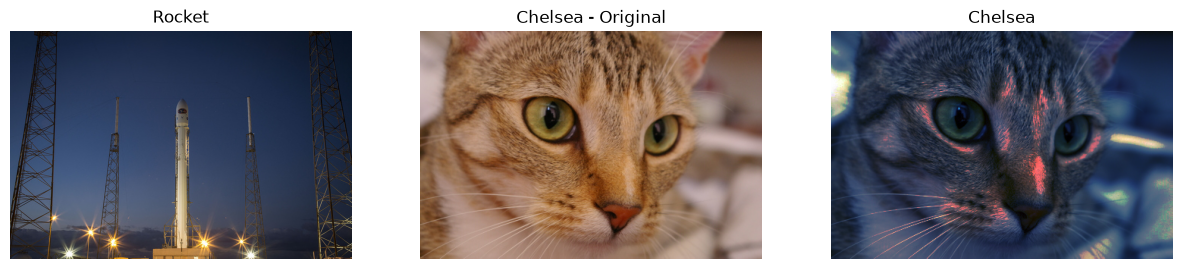

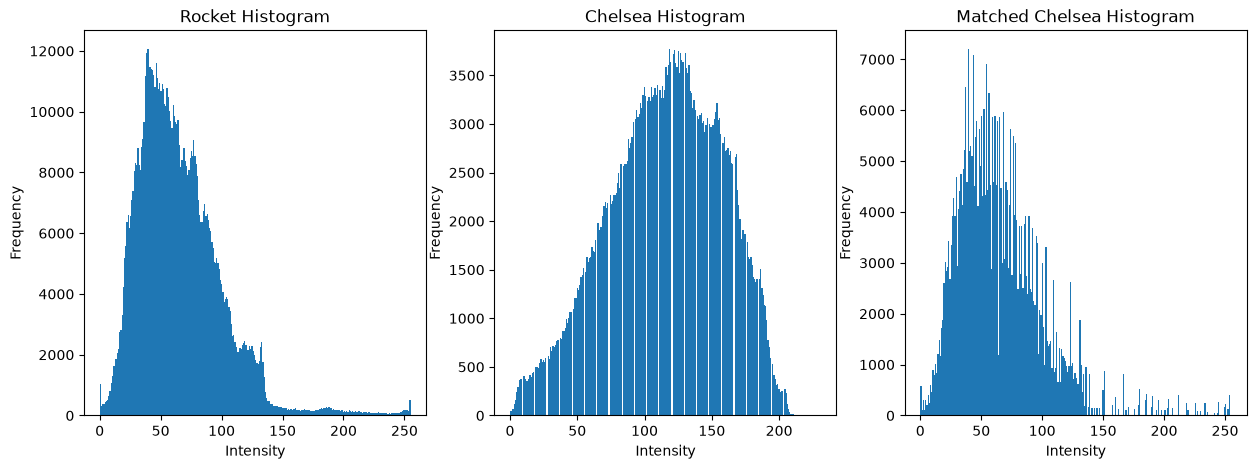

In [14]:
# load the images
rocket = data.rocket()
chelsea = data.chelsea()

# histogram matching
matched = exposure.match_histograms(
    chelsea,
    rocket,
    channel_axis=-1)

plt.figure(figsize=(15, 5))

# reference image
plt.subplot(1, 3, 1)
plt.imshow(rocket)
plt.title("Rocket")
plt.axis("off")

# original image
plt.subplot(1, 3, 2)
plt.imshow(chelsea)
plt.title("Chelsea - Original")
plt.axis("off")

# Histogram-matched image
plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title("Chelsea")
plt.axis("off")

plt.show()

plt.figure(figsize=(15, 5))

# Rocket histogram
plt.subplot(1, 3, 1)
plt.hist(rocket.ravel(), bins=256)
plt.title("Rocket Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

# Chelsea histogram
plt.subplot(1, 3, 2)
plt.hist(chelsea.ravel(), bins=256)
plt.title("Chelsea Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

# Matched Chelsea histogram
plt.subplot(1, 3, 3)
plt.hist(matched.ravel(), bins=256)
plt.title("Matched Chelsea Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()